In [183]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [184]:
# IMPORT THE  DATASET 
data = pd.read_csv(r"C:\Users\Raifu Sodiq\Desktop\To do\train.csv")

In [185]:
# VIEW THE FIRST FEWS ROW 
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [186]:
# get info about each variable 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [187]:
# checking the total duplicates in the dataset 
data.duplicated().sum()

np.int64(0)

In [188]:
#Working on missing data 
# Dropping missing observation in column with less than or equal to 0.05 length of the column 
threshold = len(data) * 0.05

col_to_drop = data.columns[data.isna().sum() <= threshold]
data.dropna(subset = col_to_drop, inplace = True)


In [189]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1412 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1412 non-null   int64  
 1   MSSubClass     1412 non-null   int64  
 2   MSZoning       1412 non-null   object 
 3   LotFrontage    1161 non-null   float64
 4   LotArea        1412 non-null   int64  
 5   Street         1412 non-null   object 
 6   Alley          89 non-null     object 
 7   LotShape       1412 non-null   object 
 8   LandContour    1412 non-null   object 
 9   Utilities      1412 non-null   object 
 10  LotConfig      1412 non-null   object 
 11  LandSlope      1412 non-null   object 
 12  Neighborhood   1412 non-null   object 
 13  Condition1     1412 non-null   object 
 14  Condition2     1412 non-null   object 
 15  BldgType       1412 non-null   object 
 16  HouseStyle     1412 non-null   object 
 17  OverallQual    1412 non-null   int64  
 18  OverallCond  

In [190]:
# Drop Alley PoolQc and MiscFeature variable because it contains alot of missing observation
data.drop(columns=["Alley","MiscFeature", "PoolQC"], inplace=True)


In [191]:
# Checking col with missing data 
col_with_missing_data = data.columns[data.isna().sum()>0]
print(col_with_missing_data)

Index(['LotFrontage', 'MasVnrType', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageQual', 'GarageCond', 'Fence'],
      dtype='object')


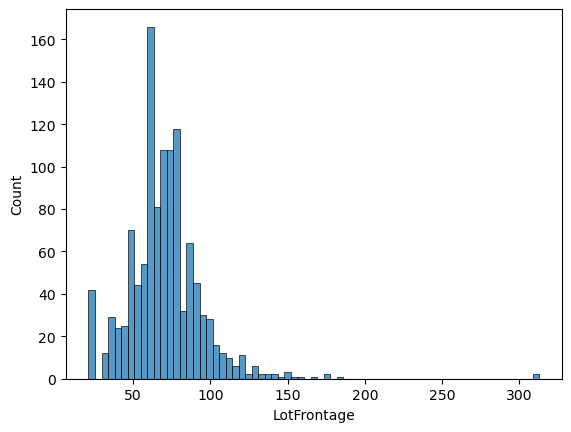

In [192]:
# Working with numeric 
sns.histplot(data = data, x = "LotFrontage")
plt.show()

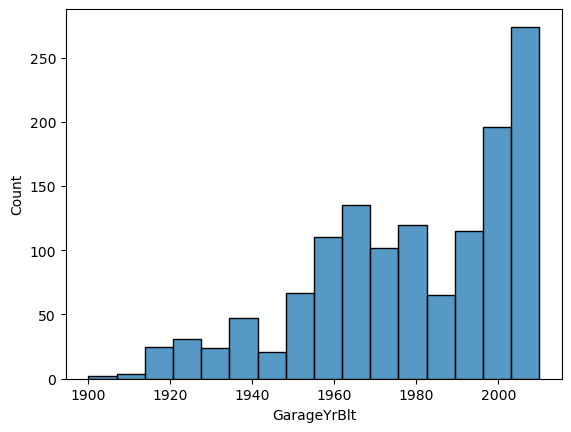

In [193]:
# Working with numeric 
sns.histplot(data = data, x = "GarageYrBlt")
plt.show()

In [132]:
data.select_dtypes("float").describe().T

,count,mean,std,min,25%,50%,75%,max
LotFrontage,1161.0,70.139535,24.576015,21.0,59.0,70.0,80.0,313.0
MasVnrArea,1412.0,105.366856,182.340601,0.0,0.0,0.0,168.0,1600.0
GarageYrBlt,1338.0,1978.596413,24.773741,1900.0,1962.0,1980.0,2002.0,2010.0


In [133]:
# filling the missing values with the meadian of mean of the observation 
data["LotFrontage"] = data["LotFrontage"].fillna(data["LotFrontage"].median())
data["GarageYrBlt"] = data["GarageYrBlt"].fillna(data["GarageYrBlt"].median())


In [262]:
# Working with Object dataset 
data["MasVnrType"] = data["MasVnrType"].fillna("None")     # None IS GIVEN IN THE DESCRIPTION TO REPRESENT THOSE THAT DIDNOT HAVE 

col_umn = data.columns[data.isna().sum() > 0]
for col in col_umn:
    data[col].fillna("NA", inplace = True)      # NA IS GIVEN IN THE DATA DESCRIPTION TO REPRESENT THOSE THAT DIDNOT HAVE 


In [197]:
data.info()    # Data is now clean with no missing number 

<class 'pandas.core.frame.DataFrame'>
Index: 1412 entries, 0 to 1459
Data columns (total 78 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1412 non-null   int64  
 1   MSSubClass     1412 non-null   int64  
 2   MSZoning       1412 non-null   object 
 3   LotFrontage    1412 non-null   object 
 4   LotArea        1412 non-null   int64  
 5   Street         1412 non-null   object 
 6   LotShape       1412 non-null   object 
 7   LandContour    1412 non-null   object 
 8   Utilities      1412 non-null   object 
 9   LotConfig      1412 non-null   object 
 10  LandSlope      1412 non-null   object 
 11  Neighborhood   1412 non-null   object 
 12  Condition1     1412 non-null   object 
 13  Condition2     1412 non-null   object 
 14  BldgType       1412 non-null   object 
 15  HouseStyle     1412 non-null   object 
 16  OverallQual    1412 non-null   int64  
 17  OverallCond    1412 non-null   int64  
 18  YearBuilt    

# PERFROM SOME EXPLORATORY DATA ANALYSIS 


In [198]:
# BUILDING TYPES AND THERE AVERAGE PRICE 
bldg = data.groupby("BldgType")["SalePrice"].mean().sort_values().round(2).reset_index(name = "Average_price")
bldg

,BldgType,Average_price
0,2fmCon,131729.31
1,Twnhs,135911.63
2,Duplex,143254.24
3,TwnhsE,181800.58
4,1Fam,186752.26


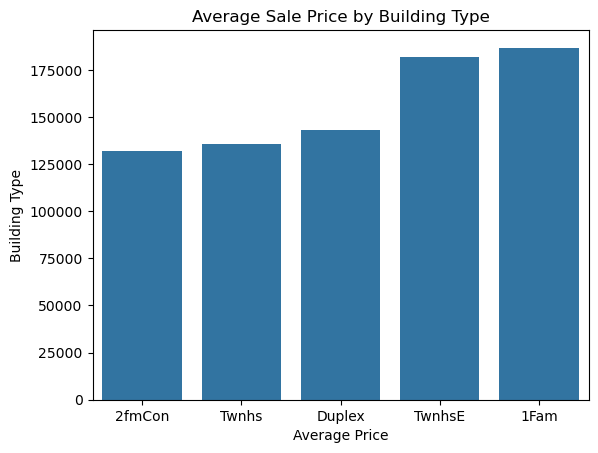

In [199]:
# Graphical representation 
sns.barplot(data = bldg, 
            x="BldgType",
            y = "Average_price"
           )

plt.title("Average Sale Price by Building Type")
plt.xlabel("Average Price")
plt.ylabel("Building Type")

plt.show()

In [200]:
         # From this it can be deduced that the Single-family Detached (1Fam)  has the height average price, follow by Two-family Conversion( 2FmCon)
        # then Duplex, Townhouse End Unit(TwnhsE) then (Townhouse Inside Unit) TwnhsI

In [201]:
# Checking the what overall condition of most of the building 

dtf = data.groupby("BldgType")["OverallCond"].value_counts().reset_index()
dtf

,BldgType,OverallCond,count
0,1Fam,5,629
1,1Fam,6,224
2,1Fam,7,188
3,1Fam,8,67
4,1Fam,4,37
5,1Fam,9,21
6,1Fam,3,17
7,1Fam,2,5
8,1Fam,1,1
9,2fmCon,5,8


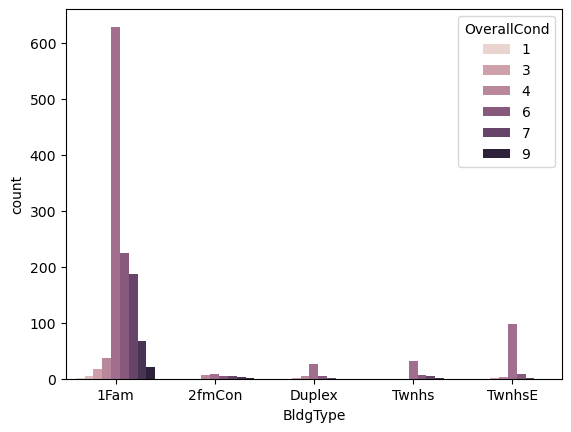

In [202]:
# Representing with a chart
sns.barplot(data = dtf, 
            x = "BldgType",
            y = "count",
            hue = "OverallCond"
           )
plt.show()

In [203]:
                # From the above dataframe and chart it can be clearly seen that mostly sold building type is 1fam (Single-family Detached).
                #  And most of the building are between average and very good condition 

array([  5,  31,   7,  91,   8,  16,   3,  36,  77,  69,  43,   1,  46,
        48,  78,  40,   4,  51,   6,  42,   2,  59,  49,  81,  88,  15,
        55,  57,  41,  24,  33,  47,  89,  10,  72,  25,  52,  44,   0,
        87,  12,  65,  53,  34,  11,  56,  95,  60,  99,  14,  94,  13,
        45,  97,  90,  76, 122,  54,  62,  20,  37,  68,  50,  30,  71,
         9,  38,  18,  39,  58,  70,  32,  35,  83,  84,  66,  19,  22,
        86,  98, 114,  93,  75,  82,  17, 106,  29,  96,  27,  92, 128,
        61,  67,  21,  26, 108,  28,  63,  73,  74,  80, 115, 126, 102,
        85,  23, 110, 117, 129, 100, 111, 104, 119, 127, 107, 135, 109,
       136, 103,  79, 125])

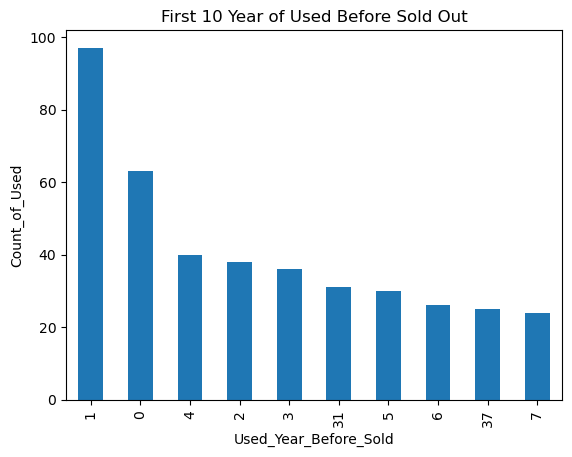

In [204]:
# How many years does it takes house before they were sold out
year_used = data["YrSold"] - data["YearBuilt"] 

# Visualize
year_used.value_counts().head(10).plot(kind = "bar", xlabel = "Used_Year_Before_Sold", ylabel = "Count_of_Used", 
                                       title = "First 10 Year of Used Before Sold Out" )
year_used.unique()

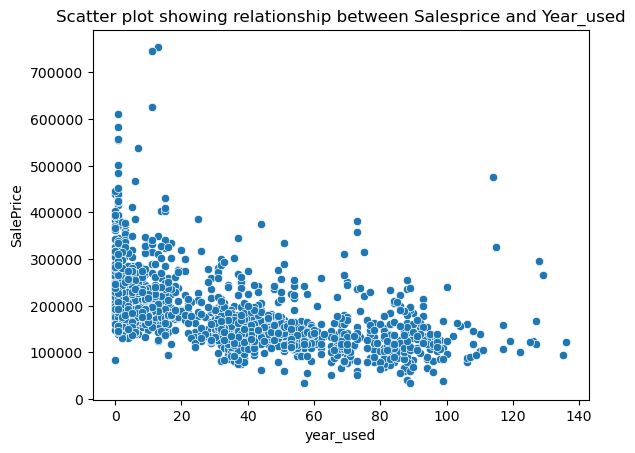

In [205]:
# Let Check the relationship between used year and and Sales price
data["year_used"] = year_used # Adding the year used colum to dataframe
# Create a scatter plot to show the relationship
sns.scatterplot( data = data, x = "year_used", y = "SalePrice")
plt.title("Scatter plot showing relationship between Salesprice and Year_used")

plt.show()

In [206]:
    # The graph let us see that as the year used increase the salesprice decreases, 
    # though most of this house were sold between 0 to 40 years     

In [207]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,Fence,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,year_used
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,NA,0,2,2008,WD,Normal,208500,5
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,NA,0,5,2007,WD,Normal,181500,31
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,NA,0,9,2008,WD,Normal,223500,7
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,0,0,NA,0,2,2006,WD,Abnorml,140000,91
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,NA,0,12,2008,WD,Normal,250000,8


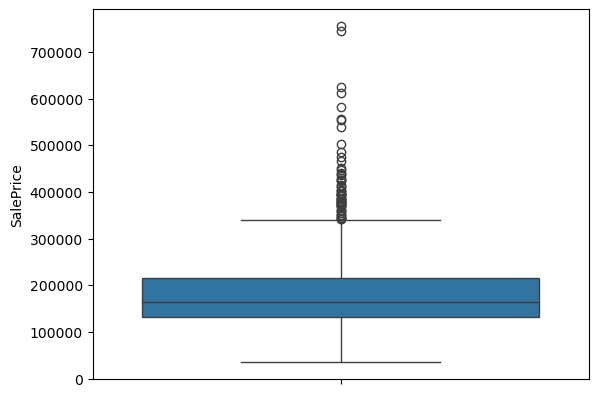

In [208]:
sns.boxplot(data = data, 
             y = "SalePrice")
plt.show()

In [209]:
# We can see that the price contails some outliers but it will not be good
# to remove them from our dataset these may be the price of those house that were used for few years before they were sold 

In [210]:
data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,Fence,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,year_used
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,NA,0,2,2008,WD,Normal,208500,5
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,NA,0,5,2007,WD,Normal,181500,31
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,NA,0,9,2008,WD,Normal,223500,7
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,0,0,NA,0,2,2006,WD,Abnorml,140000,91
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,NA,0,12,2008,WD,Normal,250000,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,...,0,0,NA,0,8,2007,WD,Normal,175000,8
1456,1457,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,...,0,0,MnPrv,0,2,2010,WD,Normal,210000,32
1457,1458,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,...,0,0,GdPrv,2500,5,2010,WD,Normal,266500,69
1458,1459,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,...,0,0,NA,0,4,2010,WD,Normal,142125,60


# Building Model to predict the price of houses 

In [211]:
#import library
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder


In [212]:
# Drop id column
data.drop(columns = "Id", inplace = True)

In [160]:
# select the depandent variable as y and independent x
y = data["SalePrice"].values
X = data.drop("SalePrice", axis = 1)

In [161]:
X.head(3)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,3SsnPorch,ScreenPorch,PoolArea,Fence,MiscVal,MoSold,YrSold,SaleType,SaleCondition,year_used
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,NA,0,2,2008,WD,Normal,5
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,NA,0,5,2007,WD,Normal,31
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,NA,0,9,2008,WD,Normal,7


In [243]:
# Encode the categorical column using OneHotEncoder and convert to dataframe

# select the categorical columns in X
cat_col = X.select_dtypes(include="object").columns

# Instantiate encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and transform categorical columns
encoded_data = encoder.fit_transform(X[cat_col])

# Convert to DataFrame 
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(cat_col), index=X.index )

# Drop categorical columns
da_ta = X.drop(columns=cat_col)

# Concatenate
da_ta = pd.concat([da_ta, encoded_df], axis=1)
da_ta = da_ta.values

In [244]:
# Split the dataframe into train and test
X_train, X_test, y_train, y_test = train_test_split( da_ta, y, test_size=0.3, random_state=42)

# Using Linear Regression 

In [245]:
# Instantiate the model
reg = LinearRegression()

In [248]:
# fit and predict on the model
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test) 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [250]:
# Evaluate the model
sco = r2_score(y_test, y_pred)
print("The R_squared value for Linear Regression is :", sco)

The R_squared value for Linear Regression is : 0.7467184775451774


# Using xgboost Regression 

In [251]:
xgb = XGBRegressor()

xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [253]:
predictions = xgb.predict(X_test)
r = r2_score(y_test, predictions)
print("The R_squared value for xgboost Regression is :", r)

The R_squared value for xgboost Regression is : 0.8614894151687622
